In [4]:
import pickle

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }

with open('minecraft_testable_data_extend3.pkl', 'rb') as f:
    testable_data = pickle.load(f)


In [6]:
import os
import sys
import numpy as np
import pandas as pd
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

experiment_folder = os.getcwd()
functional_data = os.path.join("/DATA", "Minecraft", "_DATA", "fMRI")
processed_data = os.path.join(experiment_folder, "processed_data/")
model_weights = os.path.join(experiment_folder, "model_weights/")

if not os.path.exists(processed_data):
    os.makedirs(processed_data)
if not os.path.exists(model_weights):
    os.makedirs(model_weights)
    
task = 'task-mcHERDING'
space = 'space-MNI152NLin2009cAsym'
prefix = 'desc-preproc_bold.nii.gz'

2024-12-12 10:21:44.060062: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-12 10:21:46.257571: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-12 10:21:51.061112: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [11]:
run_preprocessing = True
if run_preprocessing:
    (
    eyemask_small,
    eyemask_big,
    dme_template,
    mask,
    x_edges,
    y_edges,
    z_edges,
    ) = preprocess.get_masks()
    for key in testable_data.keys():
        subject = key[0]
        session = key[1]
        task = key[2]
        run = key[3]
        r = int(run[4])
        print(subject, session, task, run)
        fp_func = os.path.join(functional_data, subject, session, 'func',
                                   f'{subject}_{session}_{task}_{run}_{space}_{prefix}')
        if os.path.exists(os.path.join(functional_data, subject, session, 'func',
                                        f'mask_{subject}_{session}_{task}_{run}_{space}_desc-preproc_bold.p')):
            print('Already preprocessed')
        else:
            preprocess.run_participant(
                    fp_func,
                    dme_template,
                    eyemask_big,
                    eyemask_small,
                    x_edges,
                    y_edges,
                    z_edges,
                )

sub-003 ses-07R task-mcHERDING run-1
Already preprocessed
sub-003 ses-07R task-mcHERDING run-2
Already preprocessed
sub-003 ses-07R task-mcHERDING run-3
Already preprocessed
sub-003 ses-13R task-mcHERDING run-1
Already preprocessed
sub-003 ses-13R task-mcHERDING run-2
Already preprocessed
sub-003 ses-13R task-mcHERDING run-4
Already preprocessed
sub-003 ses-13R task-mcHERDING run-5
Already preprocessed
sub-004 ses-07R task-mcHERDING run-1
Already preprocessed
sub-004 ses-07R task-mcHERDING run-2
Already preprocessed
sub-004 ses-07R task-mcHERDING run-4
Already preprocessed
sub-004 ses-13 task-mcHERDING run-1
Already preprocessed
sub-004 ses-13 task-mcHERDING run-3
Already preprocessed
sub-004 ses-13 task-mcHERDING run-6
Already preprocessed
sub-005 ses-07 task-mcHERDING run-1
Already preprocessed
sub-005 ses-07 task-mcHERDING run-3
Already preprocessed
sub-006 ses-07R task-mcHERDING run-1
Already preprocessed
sub-006 ses-07R task-mcHERDING run-2
Already preprocessed
sub-006 ses-07R tas

In [12]:
calibration_points = np.array([[200-800, 166-500], [200-800, 500-500], [200-800, 833-500],
                               [600-800, 166-500], [600-800, 500-500], [600-800, 833-500],
                               [1000-800, 166-500], [1000-800, 500-500], [1000-800, 833-500],
                               [1400-800, 166-500], [1400-800, 500-500], [1400-800, 833-500]]) * (1/78.43)
calibration_points = np.tile(calibration_points, [2,1])
calibration_order = np.array([4,11,6,2,7,0,10,5,9,8,1,3]*2)

for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(subject, session, task, run)
    participant_train_data = []
    participant_train_labels = []
    participant_train_ids = []
    
    participant_test_data = []
    participant_test_labels = []
    participant_test_ids = []
  
    # Load mask and normalize it
    # 216 TRs 
    this_mask = os.path.join(functional_data, subject, session, 'func',
                             f'mask_{subject}_{session}_{task}_{run}_{space}_desc-preproc_bold.p')
    this_mask = pickle.load(open(this_mask, "rb"))
    this_mask = preprocess.normalize_img(this_mask)
    train_mask = np.copy(this_mask[...,1:25])
    test_mask = np.copy(this_mask)

    # Load labels (in visual angle)
    #this_label = preprocess.load_label(gaze_data, label_type="calibration_run")
    train_label = calibration_points[calibration_order, :]
    train_label = train_label[:, np.newaxis, :]
    train_label = np.repeat(train_label, 10, axis=1)
    test_label = np.zeros((510,10,2))
    
    # Store across runs
    participant_train_data.append(train_mask)
    participant_train_labels.append(train_label)
    participant_train_ids.append(([subject] * train_label.shape[0],[0] * train_label.shape[0]))

    # Store across run
    participant_test_data.append(test_mask)
    participant_test_labels.append(test_label)
    participant_test_ids.append(([subject] * test_label.shape[0],[0] * test_label.shape[0]))

    # Save participant file
    preprocess.save_data(
        subject + f'_{session}_{run}_train',
        participant_train_data,
        participant_train_labels,
        participant_train_ids,
        processed_data,
        center_labels=False,
    )
    preprocess.save_data(
        subject + f'_{session}_{run}_test',
        participant_test_data,
        participant_test_labels,
        participant_test_ids,
        processed_data,
        center_labels=False,
    )

sub-003 ses-07R task-mcHERDING run-1


/home/jwpark/anaconda3/envs/Eyetracking/lib/python3.10/site-packages/deepmreye/preprocess.py:340: RuntimeWarning:

Mean of empty slice

/home/jwpark/anaconda3/envs/Eyetracking/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning:

Degrees of freedom <= 0 for slice.



Saving eye data (24, 47, 29, 18) and targets (24, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-1_train
Saving eye data (510, 47, 29, 18) and targets (510, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-1_test
sub-003 ses-07R task-mcHERDING run-2
Saving eye data (24, 47, 29, 18) and targets (24, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-2_train
Saving eye data (510, 47, 29, 18) and targets (510, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-2_test
sub-003 ses-07R task-mcHERDING run-3
Saving eye data (24, 47, 29, 18) and targets (24, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-3_train
Saving eye data (510, 47, 29, 18) and targets (510, 10, 2) (NaN 0) to file /DATA3/Eyetracking/DeepMReye/processed_data/sub-003_ses-07R_run-3_test
sub-003 ses-13R task-mcHERDING run-1
Saving eye data 

In [42]:
import os
from tensorflow.keras.callbacks import Callback
class LossHistoryCallback(Callback):
  def __init__(self, filename):
    super().__init__()
    self.filename = filename
    with open(self.filename, "w") as f:
      f.write("Epoch,Training Loss\n")
  def on_epoch_end(self, epoch, logs=None):
    training_loss = logs.get('loss', 'NA')
    with open(self.filename, "a") as f:
      f.write(f"{epoch+1},{training_loss}\n")
          
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(subject, session, task, run)
    
    data = np.load(f'processed_data/{subject}_{session}_{run}_train.npz', mmap_mode='r')
    X = [data['data_' + str(b)] for b in range(24)]
    y = [data['label_' + str(b)] for b in range(24)]
    X = np.array(X)[..., np.newaxis]
    y = np.array(y)
    opts = model_opts.get_opts()
        
    opts["epochs"] = 120
    opts["gaussian_noise"] = 1.0
    lr_sched = util.step_decay_schedule(initial_lr=opts['lr'], decay_factor=0.95, num_epochs=opts["epochs"])
    
    loss_history_callback = LossHistoryCallback(filename=f'loss_history/{subject}_{session}_{run}_loss_scratch.txt')
    model, model_inference = architecture.create_standard_model(X.shape[1::], opts)
    model.fit([X, y], 
              epochs=opts["epochs"], 
              callbacks=[lr_sched, loss_history_callback], 
              use_multiprocessing=True, 
              workers=8)
    model_inference.save_weights(f'model_weights/{subject}_{session}_{run}_model_scratch.h5')

sub-003 ses-07R task-mcHERDING run-1
Epoch 1/120
1/1 [==============================] - 24s 24s/step - loss: 10.3363 - lr: 2.0000e-05
Epoch 2/120
1/1 [==============================] - 2s 2s/step - loss: 8.1669 - lr: 1.9842e-05
Epoch 3/120
1/1 [==============================] - 1s 1s/step - loss: 6.9958 - lr: 1.9683e-05
Epoch 4/120
1/1 [==============================] - 1s 1s/step - loss: 6.5011 - lr: 1.9525e-05
Epoch 5/120
1/1 [==============================] - 1s 1s/step - loss: 6.3244 - lr: 1.9366e-05
Epoch 6/120
1/1 [==============================] - 2s 2s/step - loss: 6.0684 - lr: 1.9207e-05
Epoch 7/120
1/1 [==============================] - 2s 2s/step - loss: 5.7259 - lr: 1.9049e-05
Epoch 8/120
1/1 [==============================] - 1s 1s/step - loss: 5.4252 - lr: 1.8890e-05
Epoch 9/120
1/1 [==============================] - 1s 1s/step - loss: 5.1635 - lr: 1.8731e-05
Epoch 10/120
1/1 [==============================] - 2s 2s/step - loss: 4.8918 - lr: 1.8572e-05
Epoch 11/120
1/1 [=

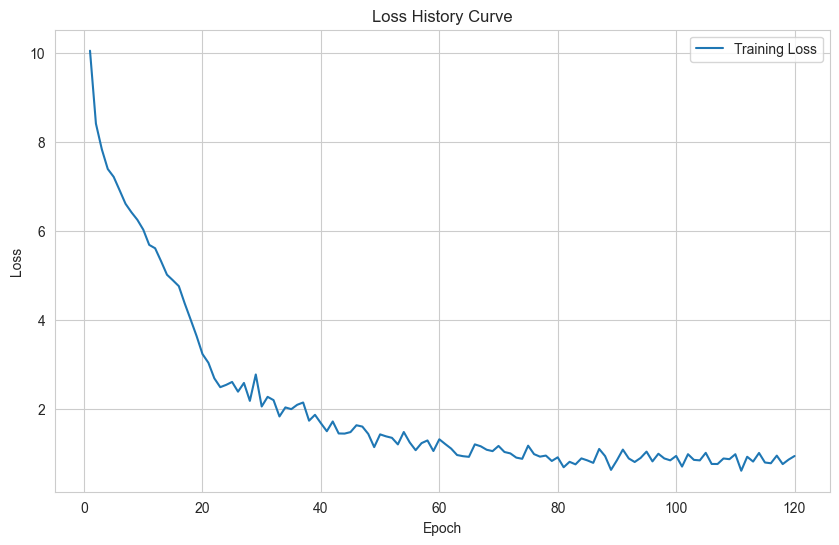

In [41]:
import matplotlib.pyplot as plt 
loss_history = pd.read_csv(f'loss_history/{subject}_{session}_{run}_loss_finetuned.txt')
plt.figure(figsize=(10, 6))
plt.plot(loss_history['Epoch'], loss_history['Training Loss'], label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History Curve")
plt.legend()
plt.grid(True)

In [43]:
calibration_points = np.array([[200-800, 166-500], [200-800, 500-500], [200-800, 833-500],
                               [600-800, 166-500], [600-800, 500-500], [600-800, 833-500],
                               [1000-800, 166-500], [1000-800, 500-500], [1000-800, 833-500],
                               [1400-800, 166-500], [1400-800, 500-500], [1400-800, 833-500]]) * (1/78.43)
calibration_points = np.tile(calibration_points, [2,1])
calibration_order = np.array([4,11,6,2,7,0,10,5,9,8,1,3]*2)

calibration_gt = calibration_points[calibration_order, :]

calibration_time = np.arange(0,24,0.1)
calibration_x = np.zeros(240)
calibration_y = np.zeros(240)
for t, time in enumerate(calibration_time):
    x = calibration_gt[int(np.floor(time)), 0]
    y = calibration_gt[int(np.floor(time)), 1]
    calibration_x[t] = x
    calibration_y[t] = y

offsets = [1, 144, 284, 494]
n_points = [24, 12, 12, 12]

subject_RMSEs = {}
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(subject, session, task, run)
    if subject not in list(subject_RMSEs.keys()):
        subject_RMSEs[subject] = []
    
    #
    test_data = np.load(f'processed_data/{subject}_{session}_{run}_test.npz', mmap_mode='r')
    
    test_X = [test_data['data_' + str(b)] for b in range(510)]
    test_y = [test_data['label_' + str(b)] for b in range(510)]
    test_X = np.array(test_X)[..., np.newaxis]
    test_y = np.array(test_y)
    
    opts = model_opts.get_opts()
    _, model_inference = architecture.create_standard_model(test_X.shape[1::], opts)
    model_inference.load_weights(f'model_weights/{subject}_{session}_{run}_model_scratch.h5')
    (pred_y, euc_pred) = model_inference.predict(test_X)
    
    pred_y = np.median(pred_y, axis=1) #Original DeepMReye evaluation funcation used np.median
    np.save(f'results/{subject}_{session}_{run}_pred_scratch.npy', pred_y)

    train_RMSE = []
    for t, time in enumerate(range(1, 25)):
        x_pred = pred_y[time,0]
        y_pred = pred_y[time,1]
        x_data = calibration_gt[t,0] #np.mean(calibration_x[t*10:(t+1)*10])
        y_data = calibration_gt[t,1] #np.mean(calibration_y[t*10:(t+1)*10])
        train_RMSE.append(np.sqrt((x_pred-x_data)**2 + (y_pred-y_data)**2))
        
    t_eval = 3
    test_RMSE = []
    for t, time in enumerate(range(offsets[t_eval], offsets[t_eval]+n_points[t_eval])):
        x_pred = pred_y[time,0]
        y_pred = pred_y[time,1]
        x_data = calibration_gt[t,0] #np.mean(calibration_x[t*10:(t+1)*10])
        y_data = calibration_gt[t,1] #np.mean(calibration_y[t*10:(t+1)*10])
        test_RMSE.append(np.sqrt((x_pred-x_data)**2 + (y_pred-y_data)**2))
    subject_RMSEs[subject].append(np.mean(test_RMSE))
    print(np.mean(train_RMSE), np.mean(test_RMSE))
print(subject_RMSEs)

sub-003 ses-07R task-mcHERDING run-1
16/16 [==============================] - 10s 516ms/step
0.36937223215251985 5.9388164177671285
sub-003 ses-07R task-mcHERDING run-2
16/16 [==============================] - 9s 509ms/step
0.5170750758883992 5.696187841057674
sub-003 ses-07R task-mcHERDING run-3
16/16 [==============================] - 9s 514ms/step
0.553555931911862 5.755895196865772
sub-003 ses-13R task-mcHERDING run-1
16/16 [==============================] - 9s 501ms/step
0.4393909681230311 5.776876486361498
sub-003 ses-13R task-mcHERDING run-2
16/16 [==============================] - 9s 504ms/step
0.47682454265583757 4.712961969657814
sub-003 ses-13R task-mcHERDING run-4
16/16 [==============================] - 9s 504ms/step
0.4884272838246944 5.591692915773471
sub-003 ses-13R task-mcHERDING run-5
16/16 [==============================] - 9s 507ms/step
0.4535199153271876 4.9119223266628
sub-004 ses-07R task-mcHERDING run-1
16/16 [==============================] - 9s 504ms/step
0.36

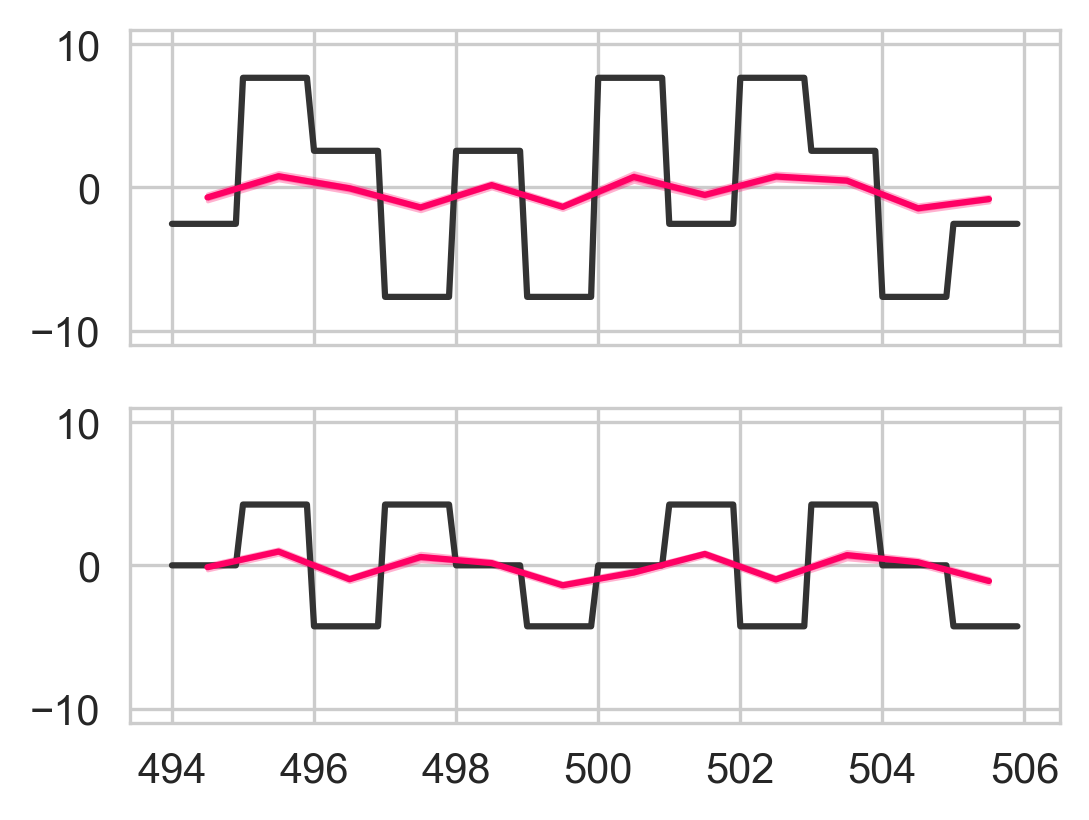

In [44]:
from scipy.stats import sem
import matplotlib.pyplot as plt

subject_pred = {}
for key in testable_data.keys():
    subject, session, task, run = key
    if subject not in subject_pred:
        subject_pred[subject] = []
    pred_y = np.load(f'results/{subject}_{session}_{run}_pred_scratch.npy')
    subject_pred[subject].append(pred_y)

for subject in subject_pred.keys():
    subject_pred[subject] = np.mean(subject_pred[subject], axis=0)

# draw the group-averaged pred_y with standard error band across subjects
time_sta = 494
time_end = time_sta + 12

group_pred_y = np.mean([subject_pred[subject] for subject in subject_pred], axis=0)
group_pred_y_se = sem([subject_pred[subject] for subject in subject_pred], axis=0)

# Plot with error bands
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300, sharex=True, sharey=True)
axes[0].plot(calibration_time[:120] + time_sta, calibration_x[:120], c='#333333')
axes[0].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 0], c='#ff0064')
axes[0].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 0] - group_pred_y_se[time_sta:time_end, 0],
                     group_pred_y[time_sta:time_end, 0] + group_pred_y_se[time_sta:time_end, 0],
                     color='#ff0064', alpha=0.3)
axes[1].plot(calibration_time[:120] + time_sta, calibration_y[:120], c='#333333')
axes[1].plot(np.arange(time_sta, time_end) + 0.5, group_pred_y[time_sta:time_end, 1], c='#ff0064')
axes[1].fill_between(np.arange(time_sta, time_end) + 0.5,
                     group_pred_y[time_sta:time_end, 1] - group_pred_y_se[time_sta:time_end, 1],
                     group_pred_y[time_sta:time_end, 1] + group_pred_y_se[time_sta:time_end, 1],
                     color='#ff0064', alpha=0.3)
axes[0].set_ylim(-11, 11)
plt.show()

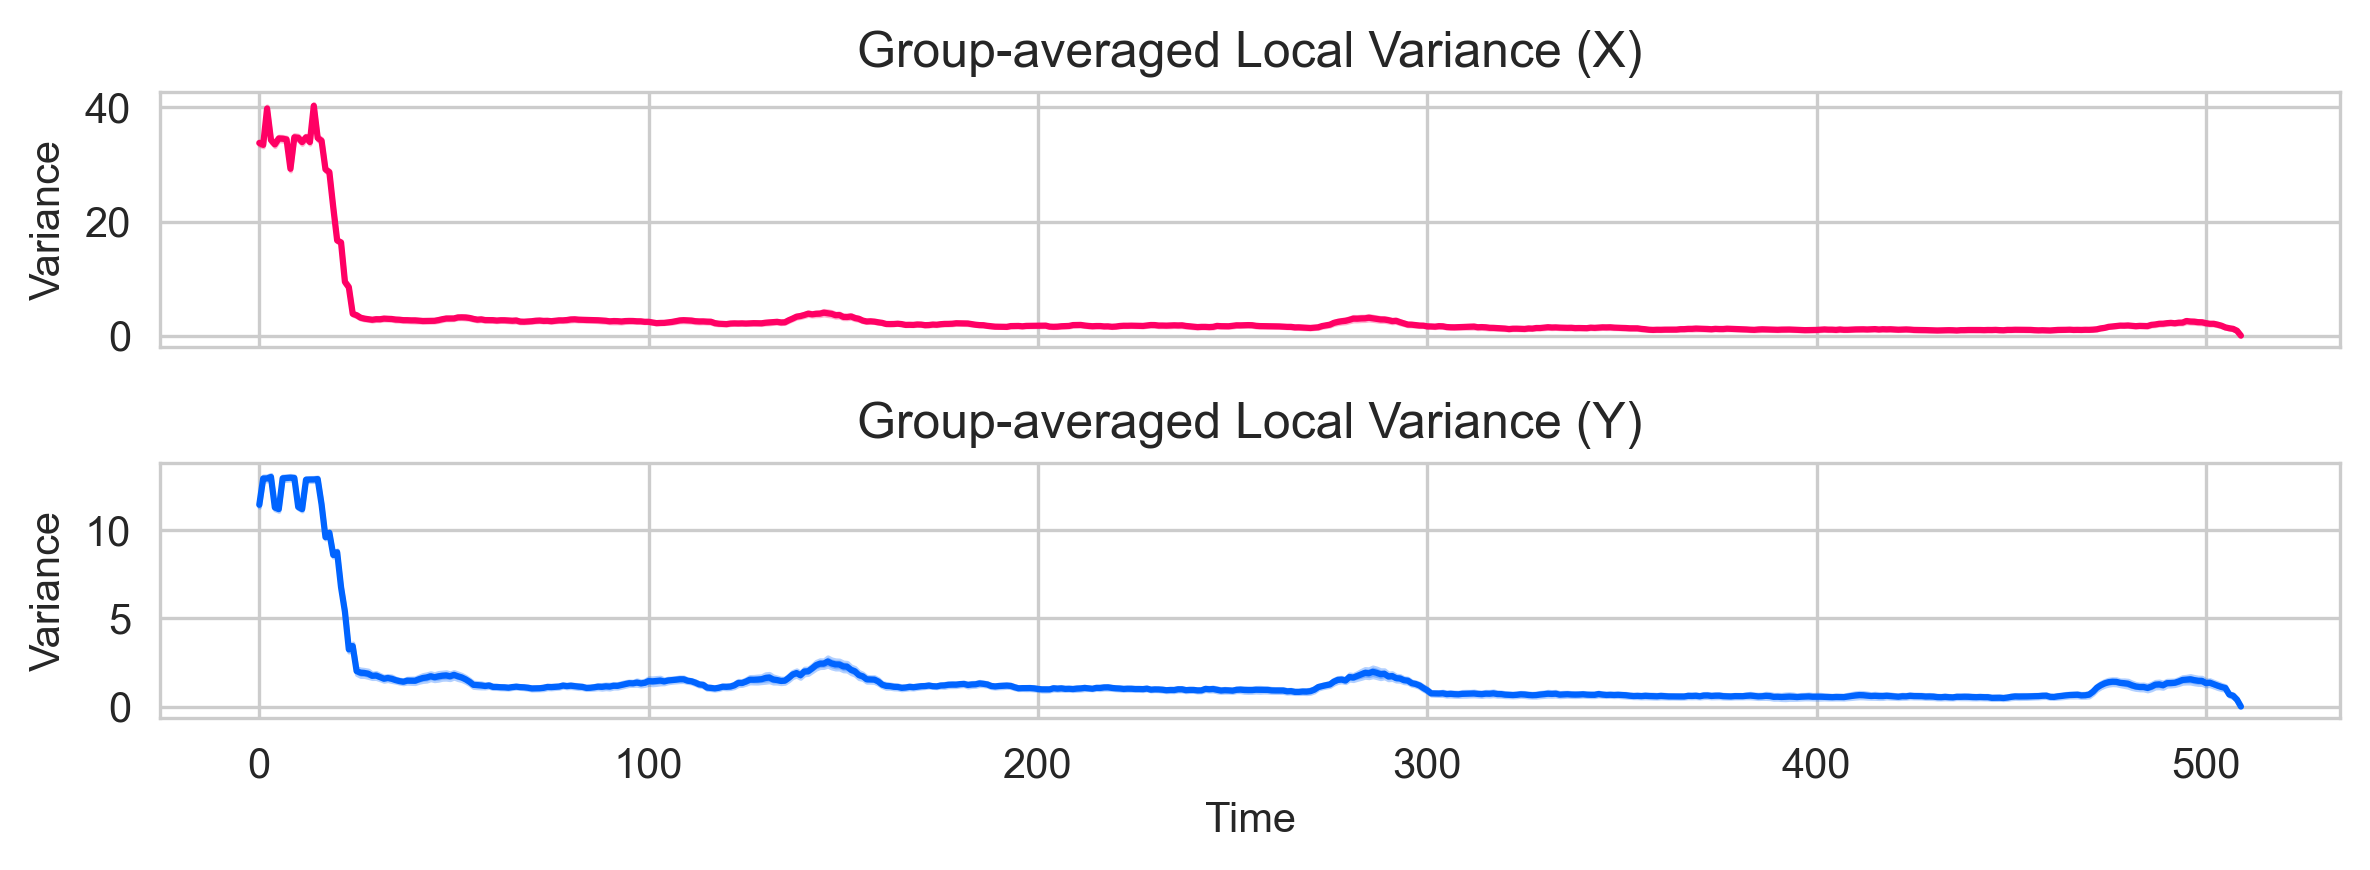

In [30]:

# Calculate local variance within each run for each subject
window_size = 10
local_variance = {subject: [] for subject in subject_pred}
for subject in subject_pred:
    for run_pred in subject_pred[subject]:
        run_local_variance = np.zeros((510,2))
        for t in range(len(run_pred)):
            if t + window_size > len(run_pred):
                window = run_pred[t:]
            else:
                window = run_pred[t:t + window_size]
            var_x = np.var(window[:, 0])
            var_y = np.var(window[:, 1])
            run_local_variance[t, 0] = var_x
            run_local_variance[t,1] = var_y
        local_variance[subject].append(run_local_variance)
    local_variance[subject] = np.mean(local_variance[subject], axis=0)

# Calculate group-averaged local variance and standard error
group_var_x = np.mean([local_variance[subject][:, 0] for subject in local_variance], axis=0)
group_var_y = np.mean([local_variance[subject][:, 1] for subject in local_variance], axis=0)
group_var_x_se = sem([local_variance[subject][:, 0] for subject in local_variance], axis=0)
group_var_y_se = sem([local_variance[subject][:, 1] for subject in local_variance], axis=0)

# Plot group-averaged local variance with error bands
time_points = np.arange(510)

fig, axes = plt.subplots(2, 1, figsize=(8, 3), dpi=300, sharex=True)
axes[0].plot(time_points, group_var_x, c='#ff0064')
axes[0].fill_between(time_points, group_var_x - group_var_x_se, group_var_x + group_var_x_se, color='#ff0064', alpha=0.3)
axes[0].set_title('Group-averaged Local Variance (X)')
axes[0].set_ylabel('Variance')

axes[1].plot(time_points, group_var_y, c='#0064ff')
axes[1].fill_between(time_points, group_var_y - group_var_y_se, group_var_y + group_var_y_se, color='#0064ff', alpha=0.3)
axes[1].set_title('Group-averaged Local Variance (Y)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Variance')

plt.tight_layout()
plt.show()

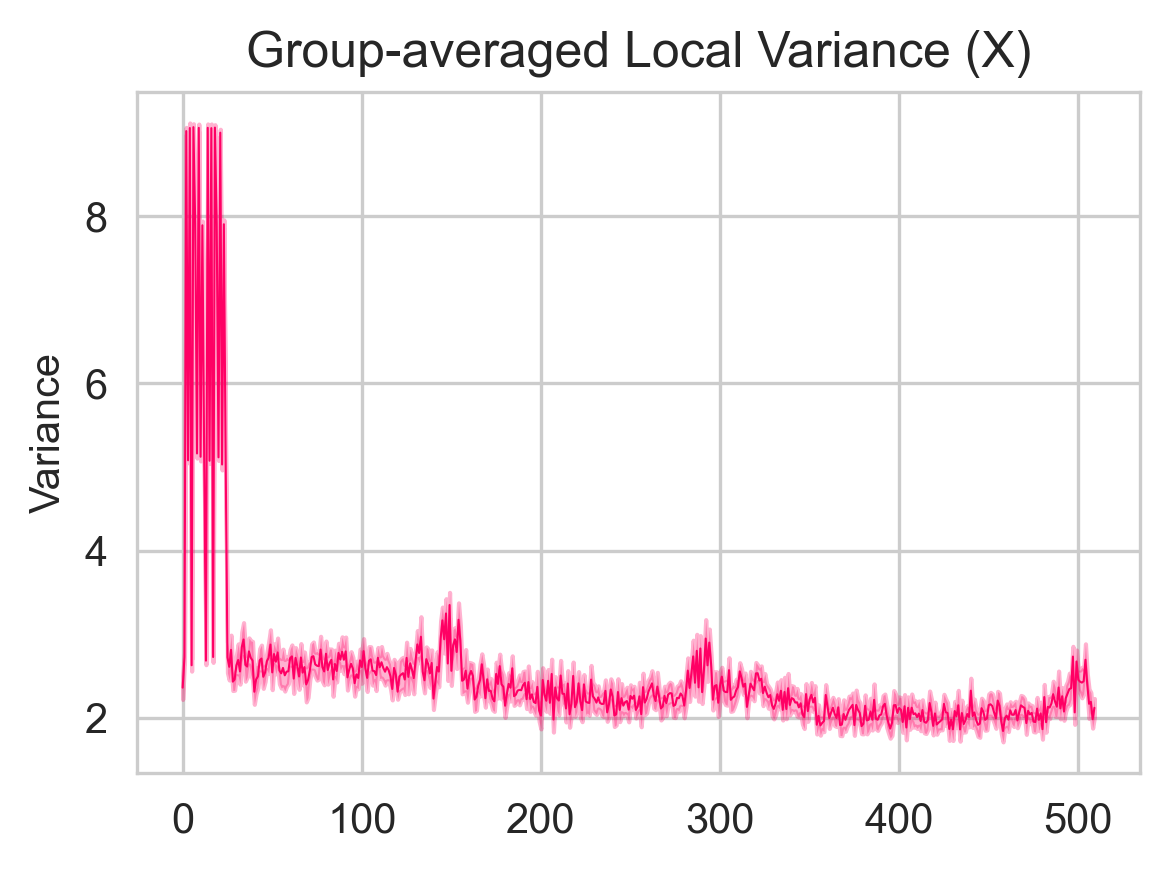

In [46]:
subject_pred = {}
for key in testable_data.keys():
    subject, session, task, run = key
    if subject not in subject_pred:
        subject_pred[subject] = []
    pred_y = np.load(f'results/{subject}_{session}_{run}_pred_scratch.npy')
    subject_pred[subject].append(pred_y)

window_size = 10
deviation = {subject: [] for subject in subject_pred}
for subject in subject_pred:
    for run_pred in subject_pred[subject]:
        run_deviation = np.zeros(510)
        for t in range(len(run_pred)):
            run_deviation[t] = np.sqrt(run_pred[t, 0]**2 + run_pred[t,1]**2)
        deviation[subject].append(run_deviation)
    deviation[subject] = np.mean(deviation[subject], axis=0)

# Calculate group-averaged local variance and standard error
group_deviation_x = np.mean([deviation[subject] for subject in subject_pred], axis=0)
group_deviation_sem = sem([deviation[subject] for subject in subject_pred], axis=0)

# Plot group-averaged local variance with error bands
time_points = np.arange(510)

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300, sharex=True)
ax.plot(time_points, group_deviation_x, c='#ff0064', lw=0.5)
ax.fill_between(time_points, group_deviation_x - group_deviation_sem, 
                     group_deviation_x + group_deviation_sem, color='#ff0064', alpha=0.3)
ax.set_title('Group-averaged Local Variance (X)')
ax.set_ylabel('Variance')

plt.tight_layout()
plt.show()

In [28]:
local_variance['sub-003']

array([[33.80827795, 11.33387852],
       [33.8514249 , 12.73079845],
       [40.03605597, 12.72079604],
       ...,
       [ 0.87898564,  0.40789712],
       [ 0.13961637,  0.08236125],
       [ 0.        ,  0.        ]])